In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
print('Libraries imported successfully')

Libraries imported successfully


In [11]:
df=pd.read_csv('./cricket.csv')
df.shape


C:\Users\Dell\AppData\Local\Temp\ipykernel_17052\2511697246.py:1: DtypeWarning: Columns (0: match_id, 1: inning, 2: over, 3: ball) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('./cricket.csv')


(150454, 21)

In [12]:
df=df.drop(['player_dismissed', 'dismissal_kind','fielder'],axis=1)
df.shape

(150454, 18)

In [13]:
df.isnull().sum()

match_id         0
inning           0
batting_team     0
bowling_team     0
over             0
ball             0
batsman          0
non_striker      0
bowler           0
is_super_over    0
wide_runs        0
bye_runs         0
legbye_runs      0
noball_runs      0
penalty_runs     0
batsman_runs     0
extra_runs       1
total_runs       1
dtype: int64

In [14]:
df['extra_runs']=df['extra_runs'].fillna(df['extra_runs'].mean())
df['total_runs']=df['total_runs'].fillna(df['total_runs'].mean())

In [15]:
df.isnull().sum()

match_id         0
inning           0
batting_team     0
bowling_team     0
over             0
ball             0
batsman          0
non_striker      0
bowler           0
is_super_over    0
wide_runs        0
bye_runs         0
legbye_runs      0
noball_runs      0
penalty_runs     0
batsman_runs     0
extra_runs       0
total_runs       0
dtype: int64

In [16]:
df.isnull().sum().sum()

0

In [41]:
X=df.drop('batting_team',axis=1)
y=df['batting_team']
le=LabelEncoder()
cols = ['bowling_team', 'batsman', 'non_striker', 'bowler']

for col in cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)
cols = ['match_id', 'inning', 'over', 'ball']

for col in cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')
print(X.dtypes) 


from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

match_id         float64
inning           float64
bowling_team       int32
over             float64
ball             float64
batsman            int32
non_striker        int32
bowler             int32
is_super_over      int64
wide_runs          int64
bye_runs           int64
legbye_runs        int64
noball_runs        int64
penalty_runs       int64
batsman_runs       int64
extra_runs       float64
total_runs       float64
dtype: object


In [42]:
print(X.dtypes)

print("\nMissing Values:")
print(X.isnull().sum())

print("\nTotal Missing Values:")
print(X.isnull().sum().sum())
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

print(f'Training samples: {X_train.shape}')
print(f'Testing samples: {X_test.shape}')

match_id         float64
inning           float64
bowling_team     float64
over             float64
ball             float64
batsman          float64
non_striker      float64
bowler           float64
is_super_over    float64
wide_runs        float64
bye_runs         float64
legbye_runs      float64
noball_runs      float64
penalty_runs     float64
batsman_runs     float64
extra_runs       float64
total_runs       float64
dtype: object

Missing Values:
match_id         0
inning           0
bowling_team     0
over             0
ball             0
batsman          0
non_striker      0
bowler           0
is_super_over    0
wide_runs        0
bye_runs         0
legbye_runs      0
noball_runs      0
penalty_runs     0
batsman_runs     0
extra_runs       0
total_runs       0
dtype: int64

Total Missing Values:
0
Training samples: (120363, 17)
Testing samples: (30091, 17)


In [43]:
X.fillna(0, inplace=True)
X = X.fillna(X.mean(numeric_only=True))
for i in range(1,15):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy Score: with {i} is {metrics.accuracy_score(y_test,y_pred)}")

Accuracy Score: with 1 is 0.9733142800172809
Accuracy Score: with 2 is 0.9472599780665315
Accuracy Score: with 3 is 0.926290252899538
Accuracy Score: with 4 is 0.8977435113489083
Accuracy Score: with 5 is 0.8771725765178957
Accuracy Score: with 6 is 0.8538433418630155
Accuracy Score: with 7 is 0.8372270778638131
Accuracy Score: with 8 is 0.8200790934166362
Accuracy Score: with 9 is 0.8031305041374497
Accuracy Score: with 10 is 0.7895051676581037
Accuracy Score: with 11 is 0.7781396430826493
Accuracy Score: with 12 is 0.7674720015951614
Accuracy Score: with 13 is 0.7563723372436941
Accuracy Score: with 14 is 0.7456714632282078


In [46]:
model=KNeighborsClassifier(n_neighbors=1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
compare = pd.DataFrame({"Actual:":y_test,"Predicted:":y_pred})
print(compare)

       Actual:  Predicted:
0            7           7
1            3           3
2           11          11
3            8           8
4            5           5
...        ...         ...
30086        1           1
30087        1           1
30088        8           8
30089       13          13
30090        6           6

[30091 rows x 2 columns]


In [48]:
print(f'Accuracy score: {metrics.accuracy_score(y_pred,y_test)}')

Accuracy score: 0.9733142800172809


In [52]:
cm=metrics.confusion_matrix(y_pred,y_test)
print(cm)

[[3181    3   15    0   17    0   14   10    0   10    1    0   10    5]
 [   2 1740    4    0    7    1    2    5    1    9    0    0    5    1]
 [   4   10 3308    8    7    1   15    7    2   15    0    0   16    4]
 [   0    0    2  653    1    0    5    7    0    0    2    2    3    1]
 [   8    6    8    3 3437    0   14   15    4   16    4    1   24    8]
 [   3    4    0    0    1  317    5    0    2    0    0    0    1    0]
 [   8    5   11    2   19    0 3418    6    7    9    1    2   14    9]
 [   9    2   12    5    9    0    8 3690    2    8    2    4    6    3]
 [   7    2    2    0    4    0    6    2 1057    2    0    0    5    3]
 [   6   10    6    0   21    0    8   13    1 2696    0    0   20    1]
 [   0    1    2    1    4    0    4    1    0    0  351    0    6    0]
 [   1    0    2    0    2    0    2    3    0    0    0  299    0    3]
 [   6    6   12    2   10    1   17    4    3   12    0    1 3438    2]
 [   4    0    8    4    8    0    8   12    2    3

[]

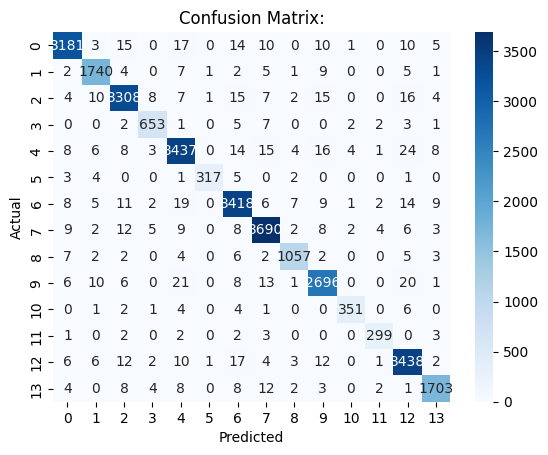

In [61]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Confusion Matrix:')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.plot()